# Анализ данных об аренде квартир в Нижнем Новгороде
Данные получены с помощью библиотеки cianparser (которая была доработана в ходе работ)

## Загрузка датасетов

In [67]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

plt.style.use("seaborn-v0_8")
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 140)

sns.set(font="DejaVu Sans")  # на случай кириллицы в графиках

In [68]:
df_1 = pd.read_csv("room_1.csv") #Однокомнатные квартиры
df_2 = pd.read_csv("room_2.csv") #Двухкомнатные квартиры
df_3 = pd.read_csv("room_3.csv") #Трехкомнатные квартиры
df_4 = pd.read_csv("room_4.csv") #Четырехкомнатные квартиры

print("Размер датасетов: ")
print(f"1-комн. квартиры: {df_1.shape}")
print(f"2-комн. квартиры: {df_2.shape}")
print(f"3-комн. квартиры: {df_3.shape}")
print(f"4-комн. квартиры: {df_4.shape}")

Размер датасетов: 
1-комн. квартиры: (571, 16)
2-комн. квартиры: (431, 16)
3-комн. квартиры: (156, 16)
4-комн. квартиры: (50, 16)


## Обработка пропусков и специальных значений
В данных есть техническое значение -1 для неизвестных этажей/площади и т.п. Приведём всё к NaN, кроме "rooms_count" - здесь проставим 1, 2, 3, 4 в зависимости от датасета

In [69]:
# Определим столбцы, где парсер не подтянул данные и проставил -1
cols_with_minus_one_1 = df_1.columns[(df_1 == -1).any()].tolist()
cols_with_minus_one_2 = df_2.columns[(df_2 == -1).any()].tolist()
cols_with_minus_one_3 = df_3.columns[(df_3 == -1).any()].tolist()
cols_with_minus_one_4 = df_4.columns[(df_4 == -1).any()].tolist()
print('Столбцы с техническим значением "-1" и их количество в соответствующем столбце: ')

print(f"1-комн. квартиры: ", end = " ")
for col in cols_with_minus_one_1:
    print(f"{col}: {len(df_1[df_1[col] == -1])}", end = ", ")
print()

print(f"2-комн. квартиры: ", end = " ")
for col in cols_with_minus_one_2:
    print(f"{col}: {len(df_2[df_2[col] == -1])}", end = ", ")
print()

print(f"3-комн. квартиры: ", end = " ")
for col in cols_with_minus_one_3:
    print(f"{col}: {len(df_3[df_3[col] == -1])}", end = ", ")
print()

print(f"4-комн. квартиры: ", end = " ")
for col in cols_with_minus_one_4:
    print(f"{col}: {len(df_4[df_4[col] == -1])}", end = ", ")
print()

Столбцы с техническим значением "-1" и их количество в соответствующем столбце: 
1-комн. квартиры:  floor: 445, floors_count: 445, rooms_count: 445, total_meters: 445, 
2-комн. квартиры:  floor: 269, floors_count: 269, rooms_count: 269, total_meters: 269, 
3-комн. квартиры:  floor: 56, floors_count: 56, rooms_count: 56, total_meters: 56, 
4-комн. квартиры:  floor: 50, floors_count: 50, rooms_count: 50, total_meters: 50, price_per_month: 21, 


**Наблюдение 1**: в каждом датасете в столбцах "floor", "floor_count", "rooms_count" и "total_meters" одинаковое количество технического значения "-1". Вероятнее всего парсер как-то некорректно обрабатывал эти квартиры.

**Наблюдение 2**: в датасете с 4-комн. квартирами есть пропуски в столбце "price_per_month"

Проведем проверки этих наблюдений

### Проверка наблюдения 1

In [70]:
#Проверим первую ссылку на квартиру и посмотрим, есть ли на ней информация об этаже, общем количестве этажей, количестве комнат и метраже
df_1[df_1['floor'] == -1]["url"].iloc[0]

'https://nn.cian.ru/rent/flat/325110987/?mlSearchSessionGuid=a052af03697ebafc4c01b9df8f87e7fa'

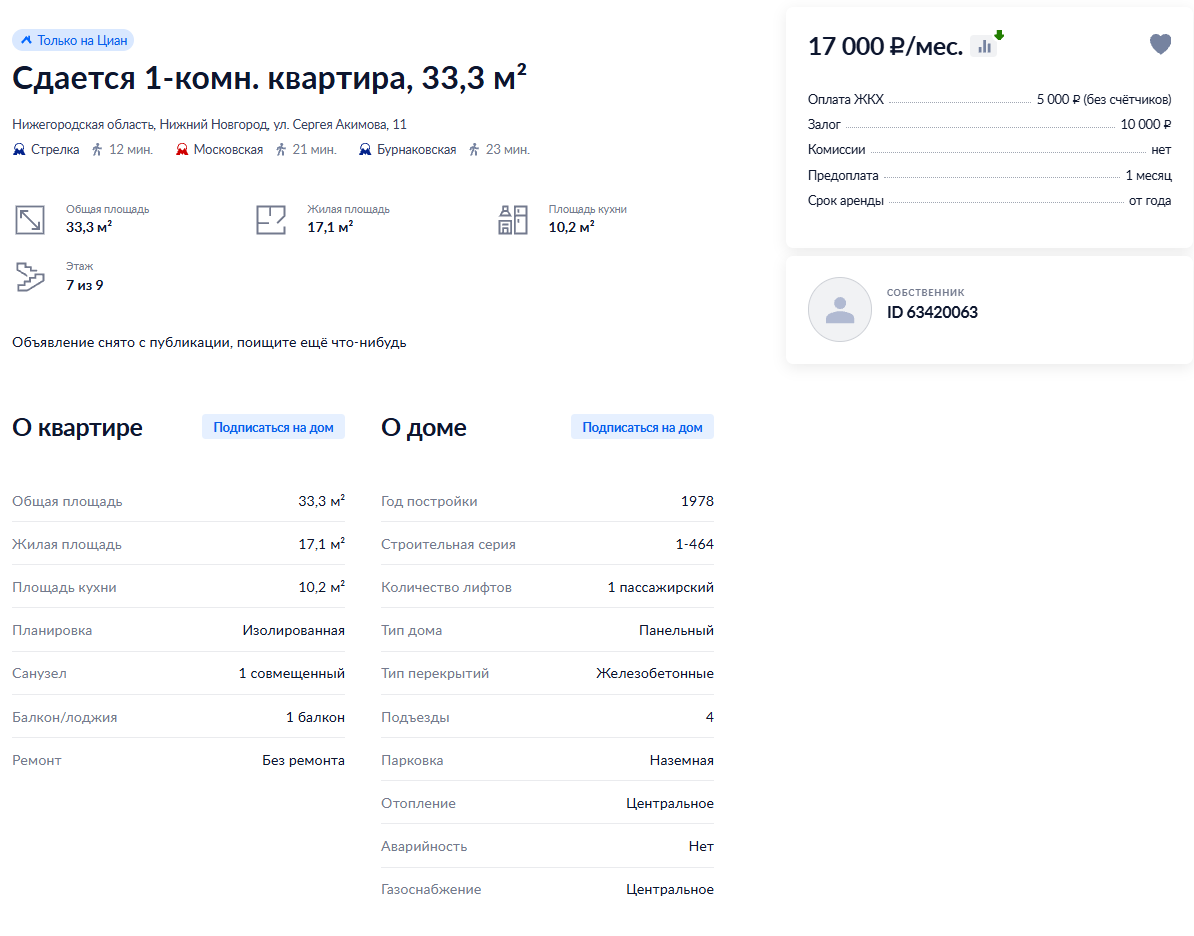

In [71]:
#Проверим вторую ссылку на квартиру и посмотрим, есть ли на ней информация об этаже, общем количестве этажей, количестве комнат и метраже
df_1[df_1['floor'] == -1]["url"].iloc[1]

'https://nn.cian.ru/rent/flat/323133018/?mlSearchSessionGuid=a052af03697ebafc4c01b9df8f87e7fa'

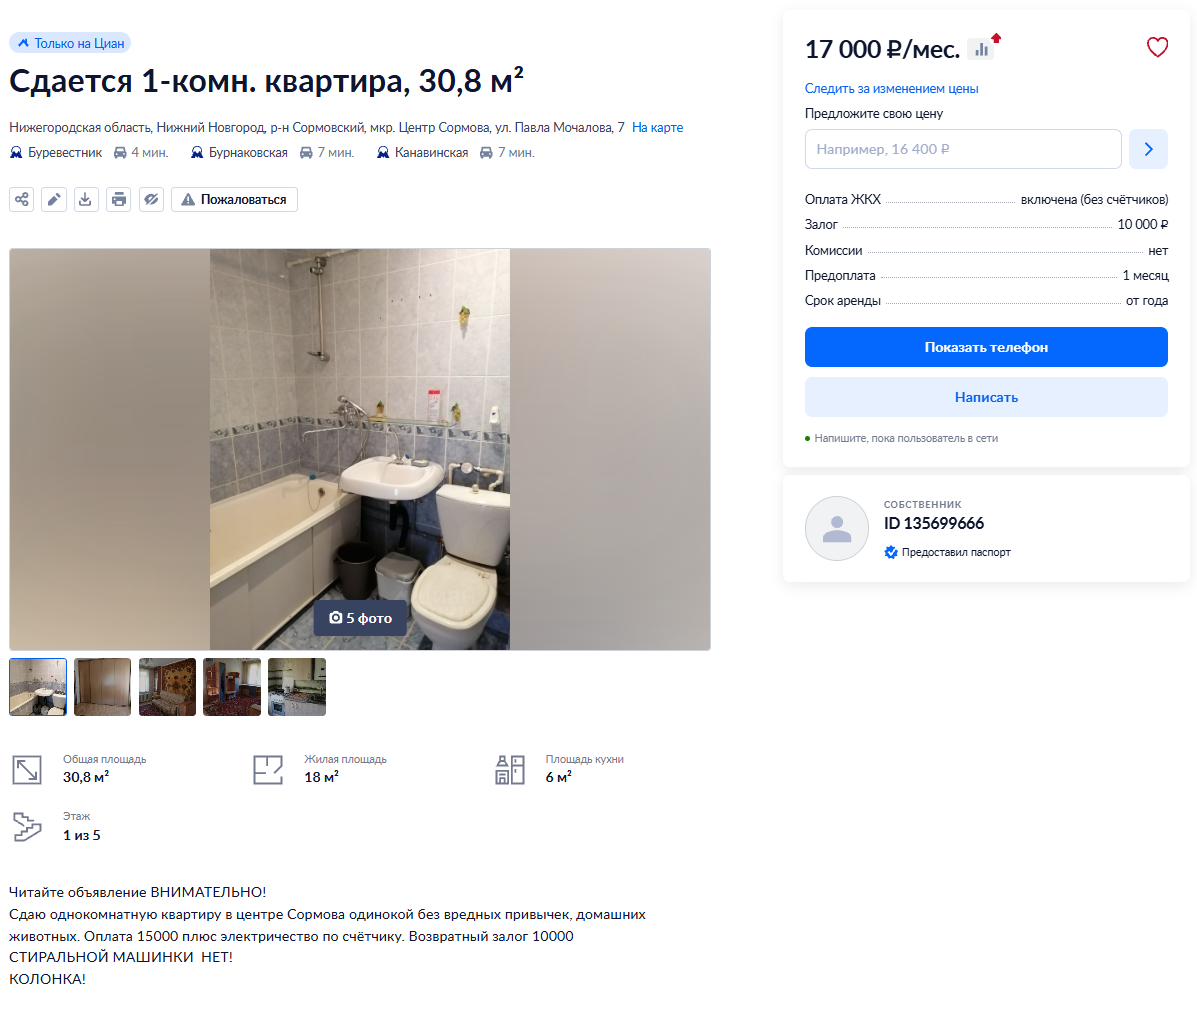

**Вывод**: на скриншотах видно, что эта информация имеется на страницах объявлений, но парсер проигнорировал ее. Это повод изучить код библиотеки на предмет ошибок

### Проверка наблюдения 2

In [72]:
# Изучим датасет 4-комн. кваритр, а именно столбец "price_per_month"
df_4[df_4['price_per_month'] == -1]["url"].iloc[0]

'https://nn.cian.ru/sale/flat/319140057/'

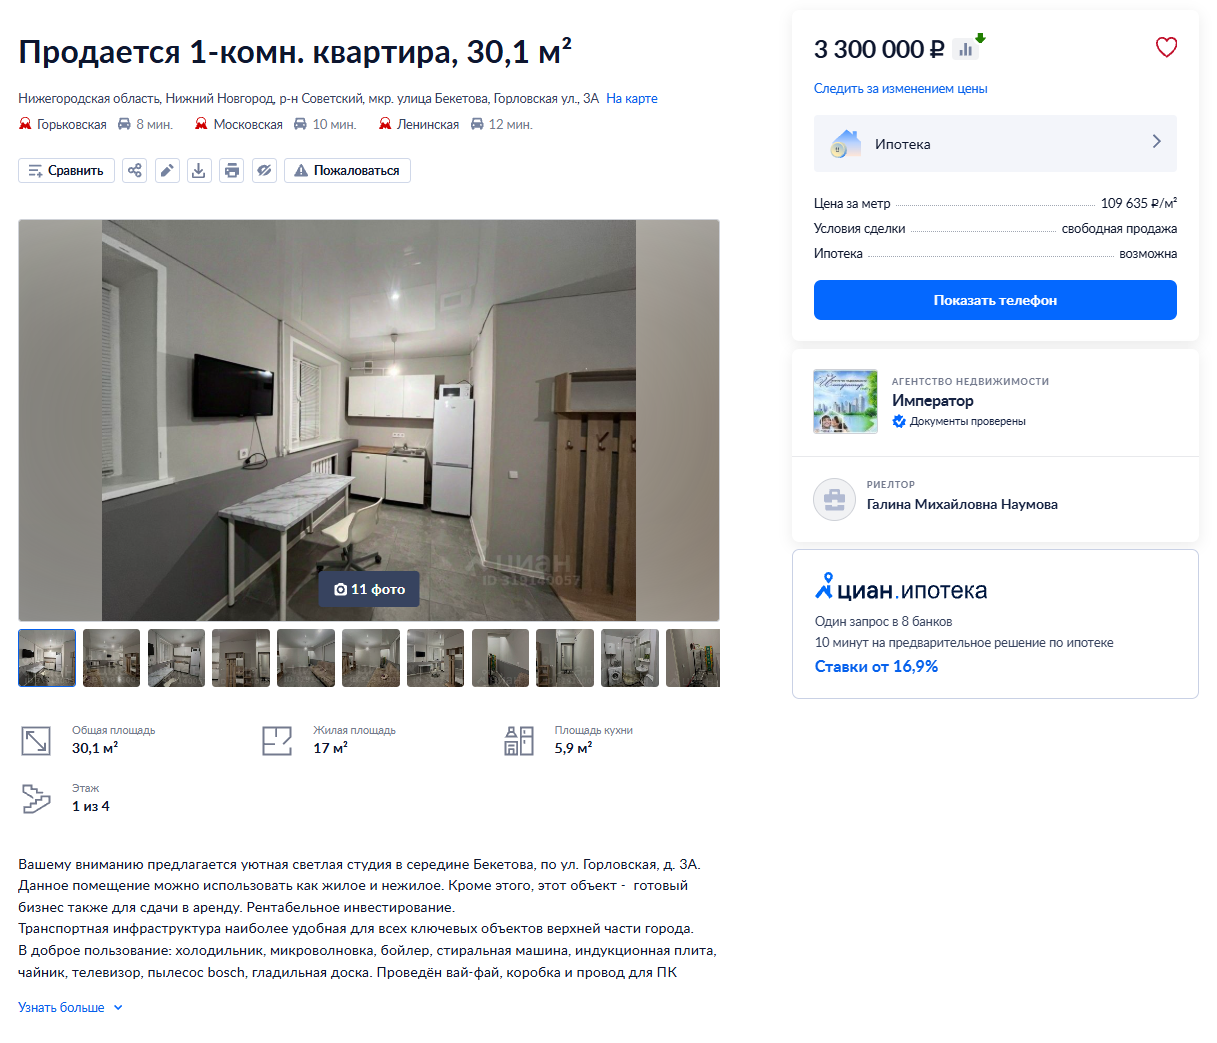

Мы видим объявление о продаже!

In [73]:
# Проверим вторую ссылку
df_4[df_4['price_per_month'] == -1]["url"].iloc[1]

'https://nn.cian.ru/sale/flat/325662848/'

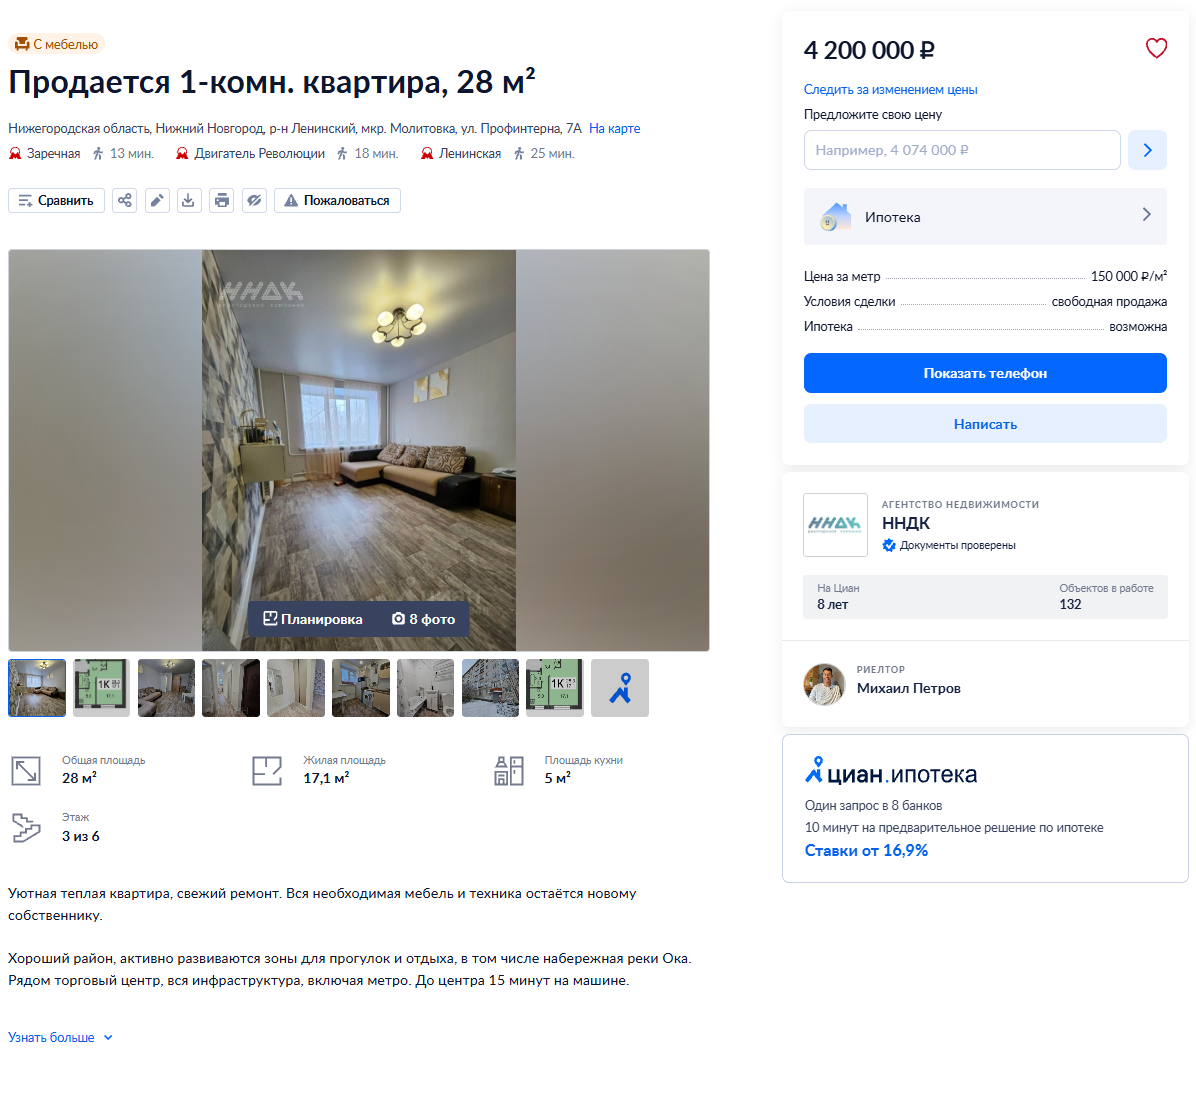

**Вывод**: на скриншотах видно, что это объявления о продаже, а не об аренде. Это повод изучить код библиотеки на предмет ошибок

## Очистка данных
В соответствующем датасете подставим значение в столбце "rooms_count". В 1-комн. квартирах - 1, в 2-комн. квартирах - 2 и т.д.

In [74]:
df_1["rooms_count"] = df_1["rooms_count"].replace({-1: 1, -1.0: 1})
df_2["rooms_count"] = df_2["rooms_count"].replace({-1: 2, -1.0: 2})
df_3["rooms_count"] = df_3["rooms_count"].replace({-1: 3, -1.0: 3})
df_4["rooms_count"] = df_4["rooms_count"].replace({-1: 4, -1.0: 4})

Удалим объявления о продаже квартир в датасете с 4-комн. квартирами

In [75]:
df_4 = df_4[df_4["price_per_month"] != -1]

Узнаем, какое количество значений "-1" в процентном отношении есть в каждом столбце в каждом датасете

In [76]:
# 
cols_with_minus_one_1 = df_1.columns[(df_1 == -1).any()].tolist()
cols_with_minus_one_2 = df_2.columns[(df_2 == -1).any()].tolist()
cols_with_minus_one_3 = df_3.columns[(df_3 == -1).any()].tolist()
cols_with_minus_one_4 = df_4.columns[(df_4 == -1).any()].tolist()
print('Столбцы с техническим значением "-1" и их количество (в %) в соответствующем столбце: ')

print(f"1-комн. квартиры: ", end = " ")
for col in cols_with_minus_one_1:
    print(f"{col}: {round((100* len(df_1[df_1[col] == -1])/len(df_1)), 2)} %", end = ", ")
print()

print(f"2-комн. квартиры: ", end = " ")
for col in cols_with_minus_one_2:
    print(f"{col}: {round((100* len(df_2[df_2[col] == -1])/len(df_2)), 2)}", end = ", ")
print()

print(f"3-комн. квартиры: ", end = " ")
for col in cols_with_minus_one_3:
    print(f"{col}: {round((100* len(df_3[df_3[col] == -1])/len(df_3)), 2)}", end = ", ")
print()

print(f"4-комн. квартиры: ", end = " ")
for col in cols_with_minus_one_4:
    print(f"{col}: {round((100* len(df_4[df_4[col] == -1])/len(df_4)), 2)}", end = ", ")
print()

Столбцы с техническим значением "-1" и их количество (в %) в соответствующем столбце: 
1-комн. квартиры:  floor: 77.93 %, floors_count: 77.93 %, total_meters: 77.93 %, 
2-комн. квартиры:  floor: 62.41, floors_count: 62.41, total_meters: 62.41, 
3-комн. квартиры:  floor: 35.9, floors_count: 35.9, total_meters: 35.9, 
4-комн. квартиры:  floor: 100.0, floors_count: 100.0, total_meters: 100.0, 


**Вывод**: Исходя из приведенной выше статистики эти столбцы лучше удалить. 
По логике, столбец "total_meters" должен нести в себе очень важную информацию. Возможно стоит рассмотреть библиотеку cianparser на предмет корректной работы.

In [77]:
#Удаляем ненужные столбцы
drop_cols = [
    "floor",
    "floors_count",
    "total_meters",
]
df_1 = df_1.drop(columns=drop_cols)
df_2 = df_2.drop(columns=drop_cols)
df_3 = df_3.drop(columns=drop_cols)
df_4 = df_4.drop(columns=drop_cols)

# Объединение датасетов и дальнейший анализ

In [78]:
df = pd.concat([df_1, df_2, df_3, df_4], axis=0, ignore_index=True)
df.head()

,author,author_type,url,location,deal_type,accommodation_type,rooms_count,price_per_month,commissions,district,street,house_number,underground
0,NaN,NaN,https://nn.cian.ru/rent/flat/323865693/?mlSear...,Нижний Новгород,rent,flat,1,35000,0,Автозаводский,улица Бориса Видяева,29,м. Парк культуры
1,NaN,NaN,https://nn.cian.ru/rent/flat/323865641/?mlSear...,Нижний Новгород,rent,flat,1,60000,0,Советский,улица Тимирязева,3к2,м. Горьковская
2,"Нижегородская область,",homeowner,https://nn.cian.ru/rent/flat/325110987/?mlSear...,Нижний Новгород,rent,flat,1,17000,0,Канавинский,улица Сергея Акимова,11,м. Стрелка
3,NaN,NaN,https://nn.cian.ru/rent/flat/326057699/?mlSear...,Нижний Новгород,rent,flat,1,60000,0,Советский,Артельная улица,8к2,м. Горьковская
4,"Нижегородская область,",homeowner,https://nn.cian.ru/rent/flat/315780621/?mlSear...,Нижний Новгород,rent,flat,1,40000,0,Нижегородский,улица Александра Хохлова,3,м. Горьковская


In [79]:
df.tail()

,author,author_type,url,location,deal_type,accommodation_type,rooms_count,price_per_month,commissions,district,street,house_number,underground
1182,Виприэлти,real_estate_agent,https://nn.cian.ru/rent/flat/322240121/,Нижний Новгород,rent,flat,4,42000,0,Нижегородский,Грузинская улица,14А,м. Горьковская
1183,Парус,real_estate_agent,https://nn.cian.ru/rent/flat/326116025/,Нижний Новгород,rent,flat,4,45000,0,Нижегородский,улица Максима Горького,43,м. Горьковская
1184,ID 10526608,unknown,https://nn.cian.ru/rent/flat/321755154/,Нижний Новгород,rent,flat,4,45000,0,Советский,Республиканская улица,43к2,м. Горьковская
1185,Самолет Плюс НижнийНовгород,real_estate_agent,https://nn.cian.ru/rent/flat/326135123/,Нижний Новгород,rent,flat,4,30000,0,Ленинский,NaN,4,м. Ленинская
1186,Александр Сергеев,unknown,https://nn.cian.ru/rent/flat/325629455/,Нижний Новгород,rent,flat,4,30000,0,Канавинский,улица Карла Маркса,45,м. Стрелка


In [80]:
df.sample(10)

,author,author_type,url,location,deal_type,accommodation_type,rooms_count,price_per_month,commissions,district,street,house_number,underground
915,Агентство недвижимости имени М. Горького,real_estate_agent,https://nn.cian.ru/rent/flat/280571100/?mlSear...,Нижний Новгород,rent,flat,2,35000,0,Советский,Артельная,12а,Горьковская
616,ID 83291365,unknown,https://nn.cian.ru/rent/flat/326141799/?mlSear...,Нижний Новгород,rent,flat,2,35000,0,Канавинский,Гордеевская улица,54,м. Московская
976,Меридиан-Недвижимость,real_estate_agent,https://nn.cian.ru/rent/flat/325684760/?mlSear...,Нижний Новгород,rent,flat,2,35000,0,Сормовский,Федосеенко,11,Буревестник
456,ID 110926659,homeowner,https://nn.cian.ru/rent/flat/295862666/?mlSear...,Нижний Новгород,rent,flat,1,44500,0,Нижегородский,Ковалихинская улица,60,м. Горьковская
49,Агент ID 97430639,unknown,https://nn.cian.ru/rent/flat/306506181/?mlSear...,Нижний Новгород,rent,flat,1,23000,0,Сормовский,улица Культуры,112,м. Буревестник
634,"Нижегородская область,",homeowner,https://nn.cian.ru/rent/flat/320564457/?mlSear...,Нижний Новгород,rent,flat,2,39000,0,Ленинский,проспект Ленина,28А,м. Заречная
479,ID 2766562,real_estate_agent,https://nn.cian.ru/rent/flat/325464081/?mlSear...,Нижний Новгород,rent,flat,1,27000,0,Нижегородский,Радужная улица,14,м. Горьковская
506,Агентствонедвижимости имени М.Горького,real_estate_agent,https://nn.cian.ru/rent/flat/310924728/?mlSear...,Нижний Новгород,rent,flat,1,50000,0,Советский,2-я Оранжерейная улица,4А,м. Горьковская
871,ID 113813795,homeowner,https://nn.cian.ru/rent/flat/325635211/?mlSear...,Нижний Новгород,rent,flat,2,45000,0,Канавинский,Движенцев,32А,Пролетарская
907,Виприэлти,real_estate_agent,https://nn.cian.ru/rent/flat/326001373/?mlSear...,Нижний Новгород,rent,flat,2,60000,0,Советский,Генкиной,46,Горьковская


Рассмотрим столбец "author"

In [81]:
df["author"].value_counts().head(60)

author
Нижегородская область,                      125
Агентство недвижимости имени М. Горького     82
Агентствонедвижимости имени М.Горького       77
Виприэлти                                    23
Владис                                       19
Агент ID 97430639                            12
Денис Тихонов                                12
Сутки-52                                     10
Марианна Роговцова                            9
Компания Дарьи Каплун                         9
Парус                                         7
Денис Тихонов                                 7
Самолет Плюс НижнийНовгород                   7
Чекни                                         6
Монолит                                       6
Анна Дюжева                                   5
Агент ID 89257458                             5
Агент ID 49523563                             4
Елена Кухарчук                                4
Компания Дарьи Каплун                         4
ID 10526608                      

**Вывод 1**: видим среди авторов "Нижегородская область". Это явно какая-то ошибка, поэтому эти данные заменим на NaN.

**Вывод 2**: есть запись в формате "Агент ID число", "ID число", "Число". Удалим слова "Агент" и "ID"

**Вывод 3**: судя по первым значениям у нас есть "Агентство недвижимости имени М. Горького" и "Агентствонедвижимости имени М. Горького", что является одним и тем же. Необходимо обработать этот недочет в данных.

In [82]:
# Заменим "Нижегородская область," на "NaN"
df["author"] = df["author"].replace(r'.*Нижегородская область.*', np.nan, regex=True)

# Заменяем "Агент" или "ID" (в любом регистре) на пустую строку
df["author"] = df["author"].str.replace(r"Агент\s|ID\s", "", case=False, regex=True).str.strip()
df["author"].head(20)

def clean_text(text):
    if not isinstance(text, str): return ""
    # Нижний регистр + удаление пробелов
    return "".join(text.lower().split())

# Создаем временный столбец для сравнения
df['author_clean'] = df['author'].apply(clean_text)
df["author_clean"].value_counts().head(60)


author_clean
                                        369
агентствонедвижимостиименим.горького    159
виприэлти                                23
денистихонов                             19
владис                                   19
97430639                                 15
компаниядарьикаплун                      13
марианнароговцова                        12
самолетплюснижнийновгород                11
сутки-52                                 10
89257458                                  8
парус                                     7
чекни                                     6
монолит                                   6
10526608                                  6
аннадюжева                                5
ольгаосадач                               5
11480726                                  5
натальяшерейко                            5
49523563                                  4
еленакухарчук                             4
96835486                                  4
домклик            

In [83]:
df.isna().sum()

author                369
author_type           244
url                     0
location                0
deal_type               0
accommodation_type      0
rooms_count             0
price_per_month         0
commissions             0
district                8
street                 13
house_number            1
underground            30
author_clean            0
dtype: int64

In [84]:
print("Количество уникальных значений в каждом столбце")
for col in df.columns:
    print(f"{col}: {df[col].nunique()}")

Количество уникальных значений в каждом столбце
author: 425
author_type: 4
url: 1187
location: 1
deal_type: 1
accommodation_type: 1
rooms_count: 4
price_per_month: 85
commissions: 1
district: 13
street: 443
house_number: 321
underground: 30
author_clean: 407


**Наблюдение 3**: у столбцов "location", "deal_type", "accommodation_type" и "commissions" всего одно уникальное значение. Посмотрим, что это за значения.

In [85]:
uniq_col = ["location", "deal_type", "accommodation_type", "commissions"]
for col in uniq_col:
    print(f"Уникальное значение столбца {col}: {df[col].unique()[0]}")

Уникальное значение столбца location: Нижний Новгород
Уникальное значение столбца deal_type: rent
Уникальное значение столбца accommodation_type: flat
Уникальное значение столбца commissions: 0


**Вывод**: столбцы "location", "deal_type", "accommodation_type" можно удалить, так как не несут в себе какой-либо информации. А вот результаты анализа столбца "commissions" вызывают вопросы. Проверим сначала, есть ли вообще информация о комиссии на страницах объявлений. В ранее приведенных примерах комиссии не было. Проверим другие ссылки.

In [86]:
df["url"].iloc[3]

'https://nn.cian.ru/rent/flat/326057699/?mlSearchSessionGuid=a052af03697ebafc4c01b9df8f87e7fa'

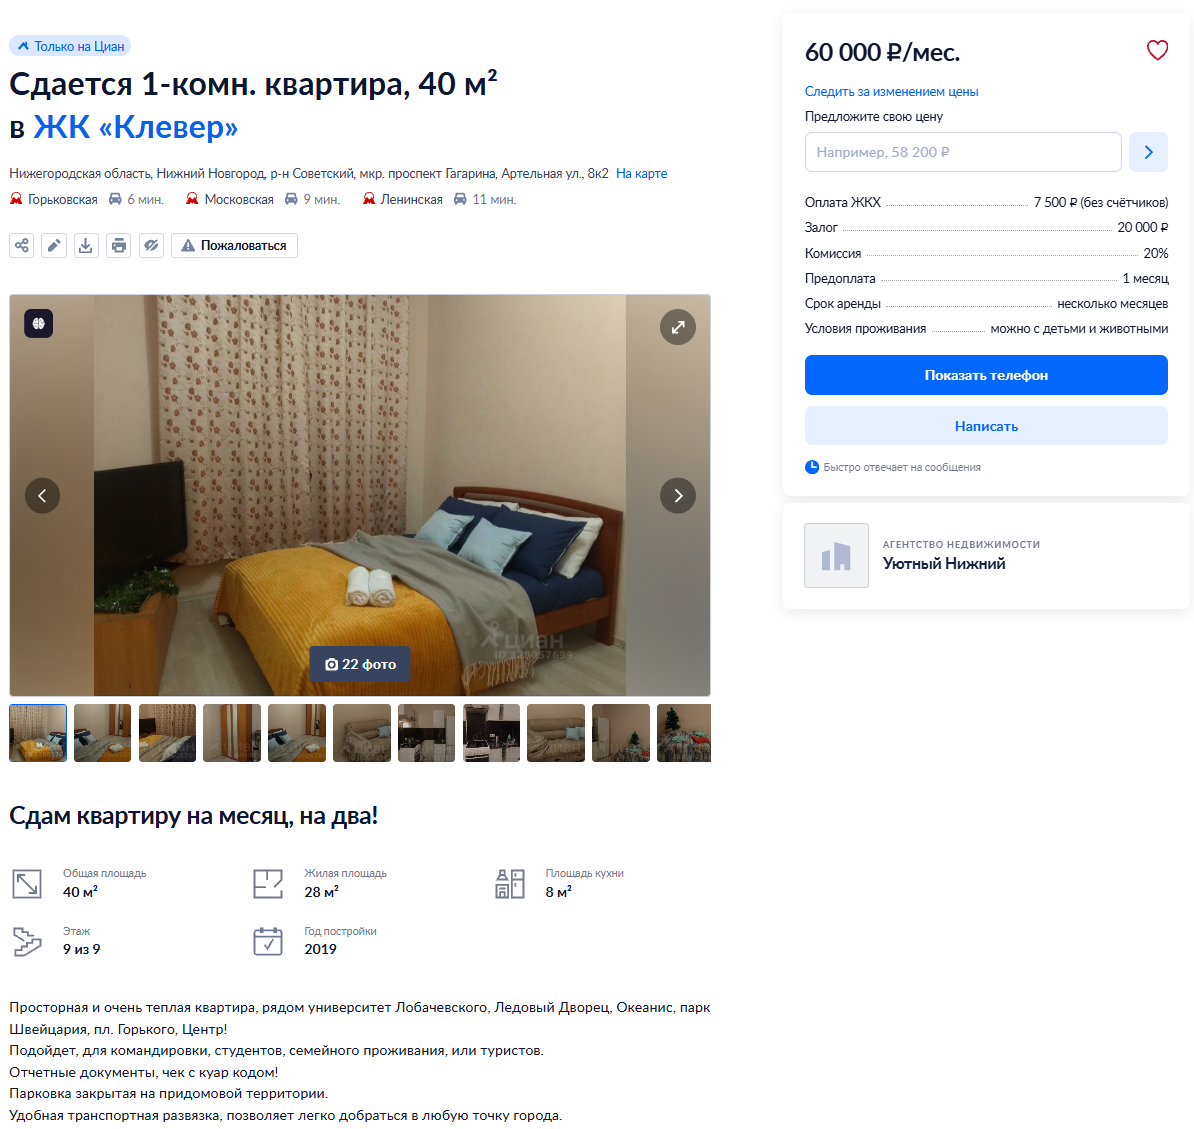

In [87]:
df["url"].iloc[30]

'https://nn.cian.ru/rent/flat/309658115/?mlSearchSessionGuid=a052af03697ebafc4c01b9df8f87e7fa'

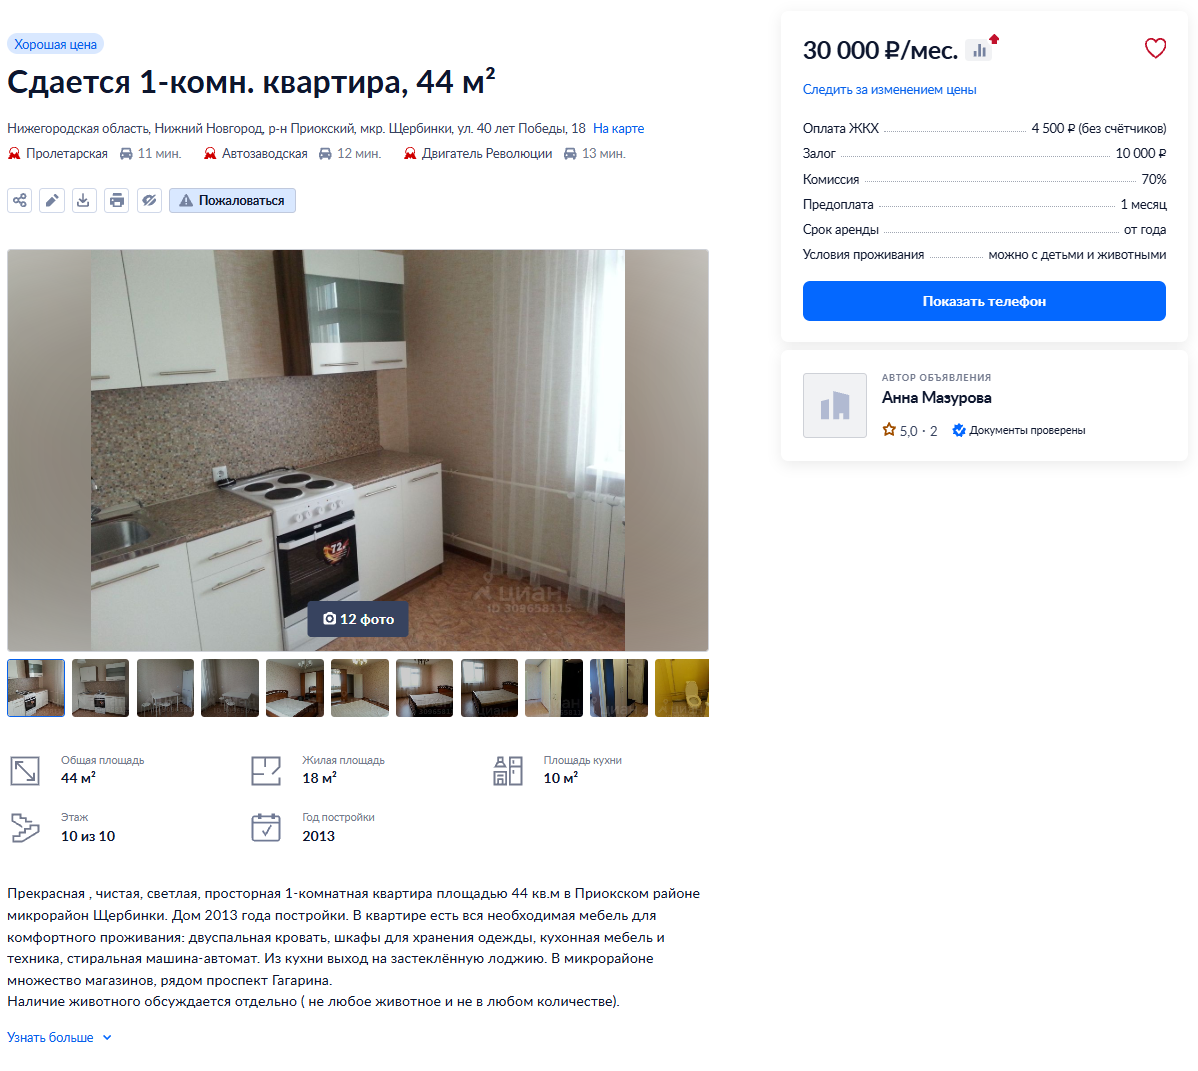

**Вывод**: информация о комиссии на страницах объявлений есть. Значит код в библиотеке некорректно работает. 
Но так как мы имеем то, что имеем, столбец "commissions" тоже можно удалить.

In [88]:
#Удаляем ненужные столбцы
df = df.drop(columns=uniq_col)

# Подолжаем анализ

In [89]:
df

,author,author_type,url,rooms_count,price_per_month,district,street,house_number,underground,author_clean
0,NaN,NaN,https://nn.cian.ru/rent/flat/323865693/?mlSear...,1,35000,Автозаводский,улица Бориса Видяева,29,м. Парк культуры,
1,NaN,NaN,https://nn.cian.ru/rent/flat/323865641/?mlSear...,1,60000,Советский,улица Тимирязева,3к2,м. Горьковская,
2,NaN,homeowner,https://nn.cian.ru/rent/flat/325110987/?mlSear...,1,17000,Канавинский,улица Сергея Акимова,11,м. Стрелка,
3,NaN,NaN,https://nn.cian.ru/rent/flat/326057699/?mlSear...,1,60000,Советский,Артельная улица,8к2,м. Горьковская,
4,NaN,homeowner,https://nn.cian.ru/rent/flat/315780621/?mlSear...,1,40000,Нижегородский,улица Александра Хохлова,3,м. Горьковская,
...,...,...,...,...,...,...,...,...,...,...
1182,Виприэлти,real_estate_agent,https://nn.cian.ru/rent/flat/322240121/,4,42000,Нижегородский,Грузинская улица,14А,м. Горьковская,виприэлти
1183,Парус,real_estate_agent,https://nn.cian.ru/rent/flat/326116025/,4,45000,Нижегородский,улица Максима Горького,43,м. Горьковская,парус
1184,10526608,unknown,https://nn.cian.ru/rent/flat/321755154/,4,45000,Советский,Республиканская улица,43к2,м. Горьковская,10526608
1185,Самолет Плюс НижнийНовгород,real_estate_agent,https://nn.cian.ru/rent/flat/326135123/,4,30000,Ленинский,NaN,4,м. Ленинская,самолетплюснижнийновгород


In [90]:
df.describe()

,rooms_count,price_per_month
count,1187.000000,1187.000000
mean,1.699242,42192.091828
std,0.787566,24399.136673
min,1.000000,12000.000000
25%,1.000000,29000.000000
50%,2.000000,35000.000000
75%,2.000000,50000.000000
max,4.000000,350000.000000


In [92]:
df.describe()

,rooms_count,price_per_month
count,1187.000000,1187.000000
mean,1.699242,42192.091828
std,0.787566,24399.136673
min,1.000000,12000.000000
25%,1.000000,29000.000000
50%,2.000000,35000.000000
75%,2.000000,50000.000000
max,4.000000,350000.000000


In [93]:
# Агрегируем по author_type и смотрим числовую статистику
df.groupby('author_type').describe().sort_values(by=('rooms_count', 'count'), ascending=False).style.format("{:.2f}")

In [94]:
# Агрегируем по district и смотрим числовую статистику
df.groupby('district').describe().sort_values(by=('rooms_count', 'count'), ascending=False).style.format("{:.2f}")

In [95]:
# Агрегируем по street и смотрим числовую статистику
df.groupby('street').describe().sort_values(by=('rooms_count', 'count'), ascending=False).head(10).style.format("{:.2f}")

Видим, что есть "улица Максима Горького" и есть просто "Максима Горького", есть "улица Родионова" и есть просто "Родионова". Нужно убрать обозначения "улица", "проспект", "площадь", "бульвар"

In [97]:
# Определяем список слов, которые нужно удалить
words_to_remove = ["улица", "проспект", "площадь", "бульвар"]
df["street"] = df["street"].str.lower() # Сначала приводим к нижнему регистру для единообразия
for word in words_to_remove:
    # Заменяем каждое слово на пустую строку
    df["street"] = df["street"].str.replace(word, '', regex=False)
# Удаляем лишние пробелы, которые могли появиться после удаления слов
df["street"] = df["street"].str.strip()

In [98]:
# Агрегируем по street и смотрим числовую статистику
df.groupby('street').describe().sort_values(by=('rooms_count', 'count'), ascending=False).head(10).style.format("{:.2f}")

In [99]:
# Агрегируем по underground и смотрим числовую статистику
df.groupby('underground').describe().sort_values(by=('rooms_count', 'count'), ascending=False).head(10).style.format("{:.2f}")

Видим, что есть "м. Горьковская" и есть просто "Горьковская", есть "м. Буревестник" и есть просто "Буревестник". Нужно убрать обозначения "м."

In [100]:
# Определяем список слов, которые нужно удалить
words_to_remove_2 = ["м."]
df["underground"] = df["underground"].str.lower() # Сначала приводим к нижнему регистру для единообразия
for word in words_to_remove_2:
    # Заменяем каждое слово на пустую строку
    df["underground"] = df["underground"].str.replace(word, '', regex=False)
# Удаляем лишние пробелы, которые могли появиться после удаления слов
df["underground"] = df["underground"].str.strip()

In [101]:
# Агрегируем по underground и смотрим числовую статистику
df.groupby('underground').describe().sort_values(by=('rooms_count', 'count'), ascending=False).style.format("{:.2f}")

In [102]:
df.head()

,author,author_type,url,rooms_count,price_per_month,district,street,house_number,underground,author_clean
0,NaN,NaN,https://nn.cian.ru/rent/flat/323865693/?mlSear...,1,35000,Автозаводский,бориса видяева,29,парк культуры,
1,NaN,NaN,https://nn.cian.ru/rent/flat/323865641/?mlSear...,1,60000,Советский,тимирязева,3к2,горьковская,
2,NaN,homeowner,https://nn.cian.ru/rent/flat/325110987/?mlSear...,1,17000,Канавинский,сергея акимова,11,стрелка,
3,NaN,NaN,https://nn.cian.ru/rent/flat/326057699/?mlSear...,1,60000,Советский,артельная,8к2,горьковская,
4,NaN,homeowner,https://nn.cian.ru/rent/flat/315780621/?mlSear...,1,40000,Нижегородский,александра хохлова,3,горьковская,


# Визуализация

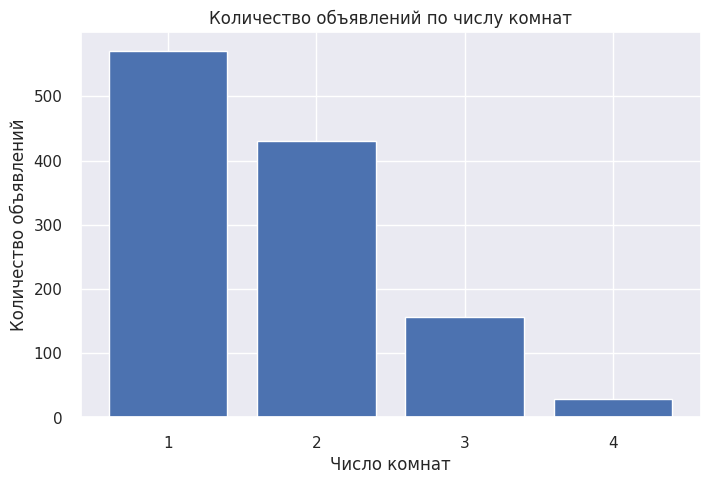

In [140]:
rooms_counts = df["rooms_count"].value_counts().sort_index()
plt.figure(figsize = (8, 5))
plt.bar(rooms_counts.index.astype(str), rooms_counts.values)
plt.title('Количество объявлений по числу комнат')
plt.xlabel('Число комнат')
plt.ylabel('Количество объявлений')
plt.show()

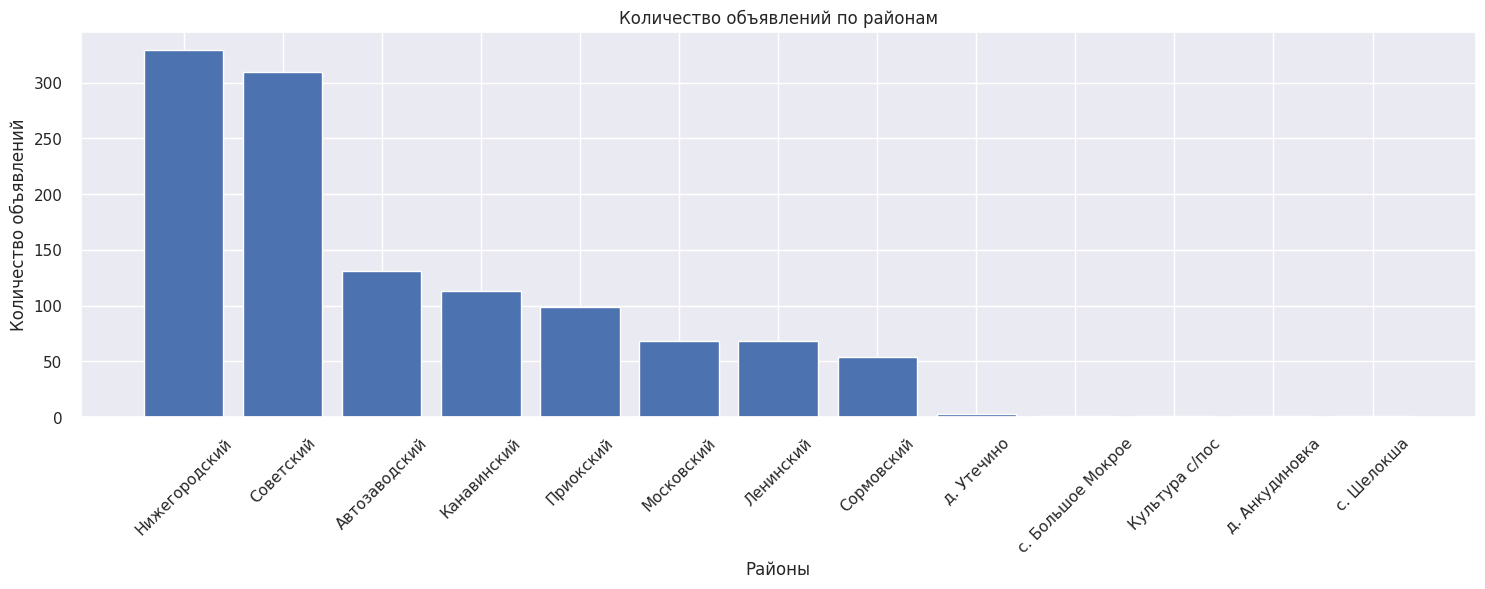

In [156]:
district_counts = df["district"].value_counts().sort_values(ascending=False)

plt.figure(figsize = (18, 5))
plt.bar(district_counts.index.astype(str), district_counts.values)
plt.title('Количество объявлений по районам')
plt.xlabel('Районы')
plt.ylabel('Количество объявлений')

plt.xticks(rotation = 45)

plt.show()

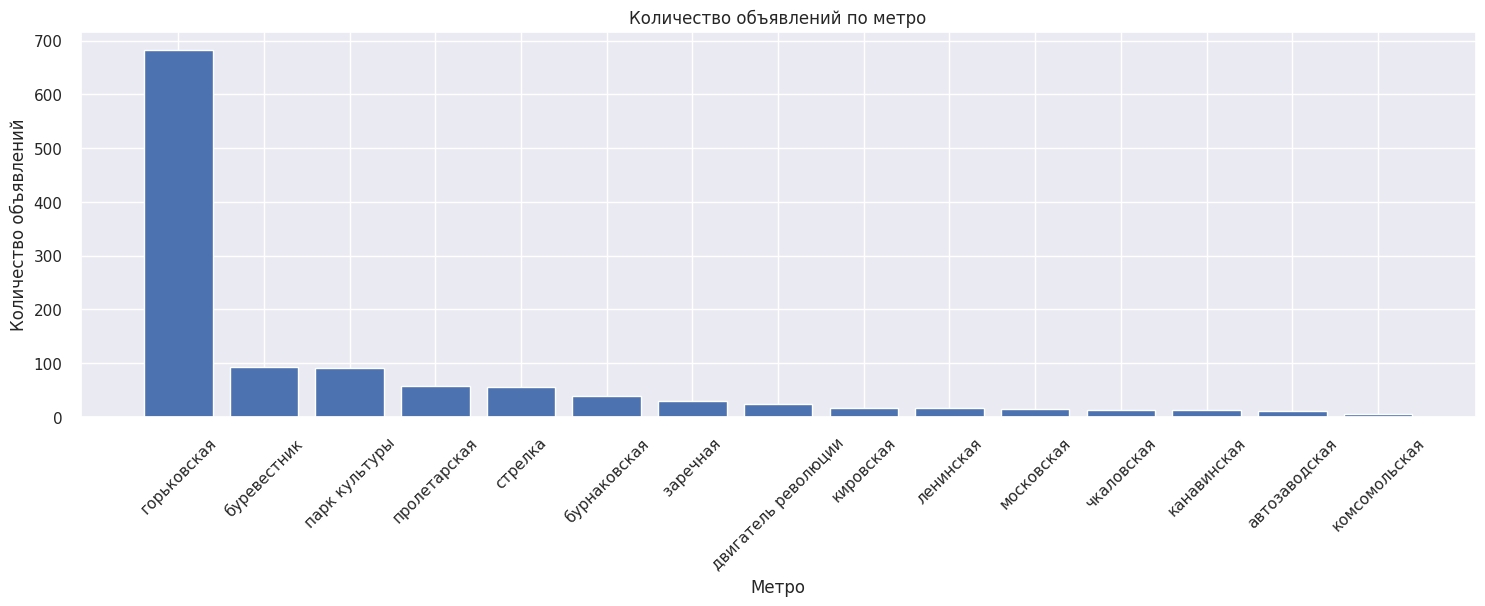

In [158]:
district_counts = df["underground"].value_counts().sort_values(ascending=False)

plt.figure(figsize = (18, 5))
plt.bar(district_counts.index.astype(str), district_counts.values)
plt.title('Количество объявлений по метро')
plt.xlabel('Метро')
plt.ylabel('Количество объявлений')

plt.xticks(rotation = 45)

plt.show()

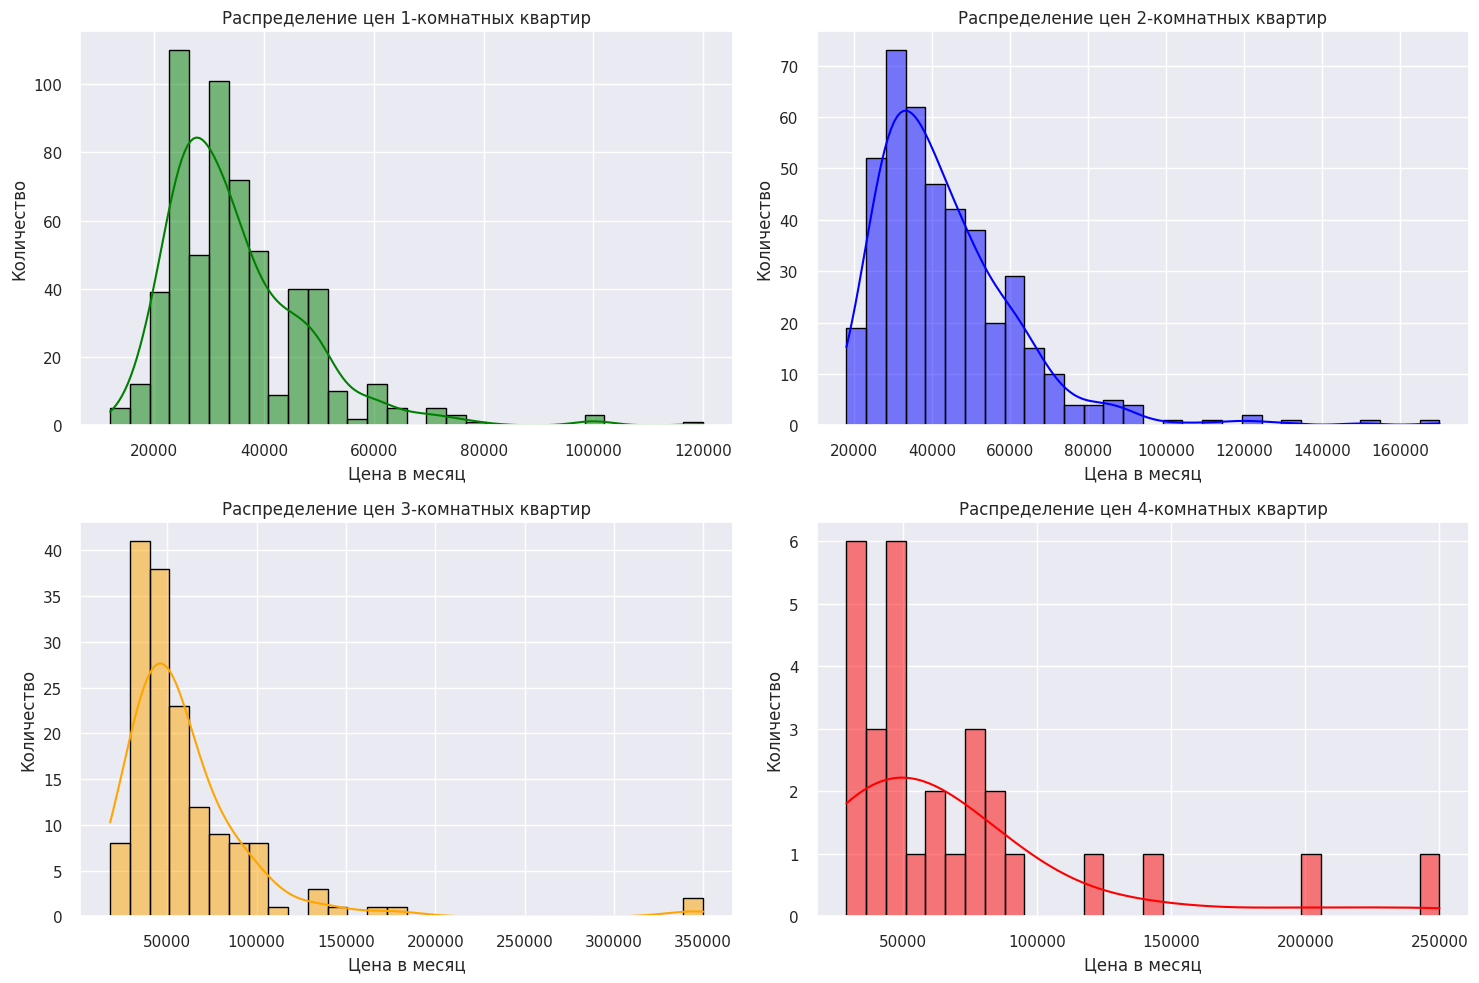

In [141]:
# Создаем сетку 2x2
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
axes = axes.flatten() # "Разглаживаем" массив осей для удобного обращения в цикле

# Список комнат, которые нас интересуют
rooms = [1, 2, 3, 4]
colors = ['green', 'blue', 'orange', 'red']

for i, room_count in enumerate(rooms):
    # Фильтруем данные для каждой комнаты
    data = df[df["rooms_count"] == room_count]["price_per_month"]
    
    # Строим гистограмму на конкретном "подграфике" (axes[i])
    sns.histplot(data, bins=30, ax=axes[i], kde=True, color=colors[i], edgecolor='black')
    
    # Настраиваем заголовки
    axes[i].set_title(f"Распределение цен {room_count}-комнатных квартир", fontsize=12)
    axes[i].set_xlabel("Цена в месяц")
    axes[i].set_ylabel("Количество")
    
# Автоматически подбираем отступы, чтобы заголовки не накладывались
plt.tight_layout()
plt.show()

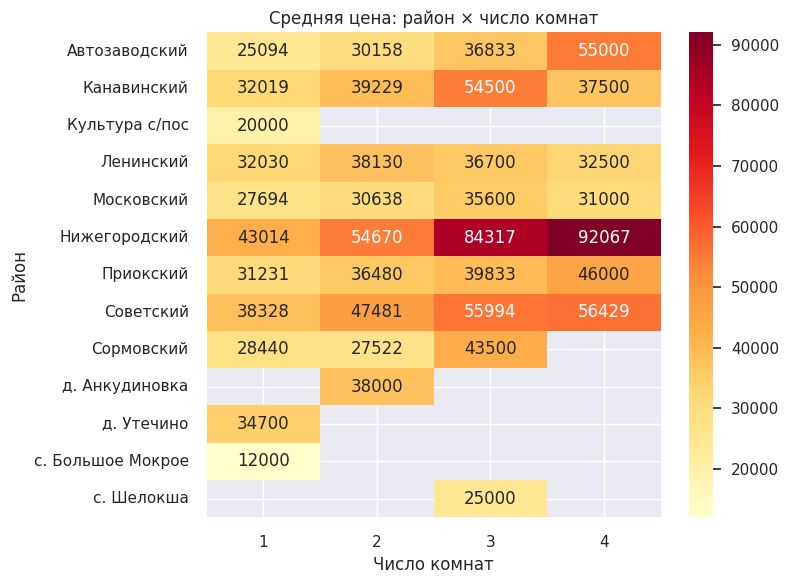

In [160]:
pivot_price = df.pivot_table(
    values="price_per_month", index="district", columns="rooms_count", aggfunc="mean"
)

plt.figure(figsize=(8, 6))
sns.heatmap(pivot_price, annot=True, fmt=".0f", cmap="YlOrRd")
plt.title("Средняя цена: район × число комнат")
plt.xlabel("Число комнат")
plt.ylabel("Район")
plt.tight_layout()
plt.show()